# No-Go Zones

Containers can have internal obstructions — divider walls, support beams, baffles — that pipette tips must avoid. The `no_go_zones` attribute on `Container` declares these regions, and `LiquidHandler` automatically distributes multi-channel operations across the free compartments.

This is a machine-agnostic feature: any liquid handler backend benefits from no-go zones defined on containers. The algorithm:

1. Splits the container's Y axis into **compartments** (free space between no-go zones)
2. Applies `edge_clearance` (default 2mm) to shrink compartments from each boundary
3. Distributes channels evenly across compartments, **center-out then back-first**
4. Centers each channel group within its compartment, respecting per-channel minimum spacing

Single-channel operations are unaffected — the channel goes to the container center as usual.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pylabrobot.resources.container import Container
from pylabrobot.resources.coordinate import Coordinate
from pylabrobot.liquid_handling.utils import (
    _get_compartments,
    center_channels_in_compartments,
    MIN_SPACING_EDGE,
)
from pylabrobot.resources.hamilton.troughs import (
    hamilton_1_trough_60mL_Vb,
    hamilton_1_trough_120mL_Vb,
    hamilton_1_trough_200mL_Vb,
)

In [2]:
def plot_container_cross_section(container, num_channels_list):
    """Plot a Y-axis cross section of a container showing no-go zones, compartments, and channels.

    Args:
        container: Container with no_go_zones defined.
        num_channels_list: List of channel counts to show (one subplot per count).
    """
    n_plots = len(num_channels_list)
    fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 5), squeeze=False)
    axes = axes[0]

    size_y = container.get_absolute_size_y()
    size_x = container.get_absolute_size_x()
    center_y = size_y / 2
    compartments = _get_compartments(container)

    for ax, n_ch in zip(axes, num_channels_list):
        # Container outline (Y on vertical axis, X on horizontal)
        ax.add_patch(plt.Rectangle((0, 0), size_x, size_y, fill=False,
                                    edgecolor="black", linewidth=2))

        # No-go zones (red)
        for flb, brt in container.no_go_zones:
            ax.add_patch(plt.Rectangle((0, flb.y), size_x, brt.y - flb.y,
                                        facecolor="red", alpha=0.3, edgecolor="red", linewidth=1))

        # Free compartments (green)
        for comp_lo, comp_hi in compartments:
            ax.add_patch(plt.Rectangle((0, comp_lo), size_x, comp_hi - comp_lo,
                                        facecolor="green", alpha=0.1, edgecolor="green",
                                        linewidth=1, linestyle="--"))

        # Channel positions
        offsets = center_channels_in_compartments(container, n_ch)
        if offsets is not None:
            for i, o in enumerate(offsets):
                tip_y = center_y + o.y
                # Draw channel center marker
                ax.plot(size_x / 2, tip_y, "o", color="navy", markersize=6, zorder=5)
                # Label
                ax.text(size_x + 1.5, tip_y, f"ch{i}", ha="left", va="center",
                        fontsize=7, color="navy")
        else:
            ax.text(size_x / 2, size_y / 2, "Cannot fit!", ha="center", va="center",
                    fontsize=12, color="red", fontweight="bold")

        ax.set_xlim(-2, size_x + 8)
        ax.set_ylim(-2, size_y + 2)
        ax.set_xlabel("X (mm)")
        ax.set_ylabel("Y (mm)")
        ax.set_title(f"{n_ch} channel{'s' if n_ch != 1 else ''}")
        ax.set_aspect("equal")

    # Legend
    legend_patches = [
        mpatches.Patch(facecolor="red", alpha=0.3, edgecolor="red", label="No-go zone"),
        mpatches.Patch(facecolor="green", alpha=0.1, edgecolor="green", label="Free compartment"),
    ]
    fig.legend(handles=legend_patches, loc="upper right", fontsize=8)

    name = container.name
    model = container.model or ""
    fig.suptitle(f"{name} ({model})\nsize_y={size_y}mm, {len(container.no_go_zones)} no-go zone(s)",
                 fontsize=11, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

## Case 1: Trough with 1 center divider

A 90mm trough with a single center divider wall at Y=44-46mm, creating 2 compartments. This is common in Hamilton 60 mL reagent troughs.

No-go zones: [(Coordinate(x=0, y=44.0, z=0), Coordinate(x=19.0, y=46.0, z=65.5))]
Compartments (usable tip center ranges): [(2.0, 42.0), (48.0, 88.0)]


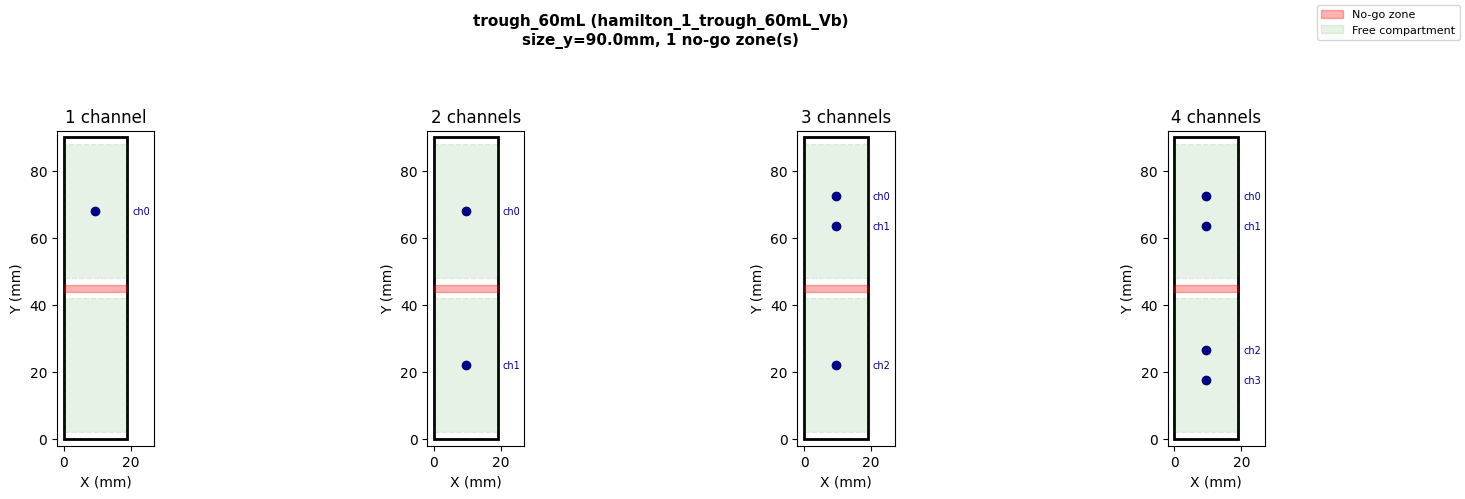

In [3]:
trough_60 = hamilton_1_trough_60mL_Vb("trough_60mL")
print(f"No-go zones: {trough_60.no_go_zones}")
print(f"Compartments (usable tip center ranges): {_get_compartments(trough_60)}")
plot_container_cross_section(trough_60, [1, 2, 3, 4])

## Case 2: Trough with 3 support beams

A 142.5mm trough with 3 internal support beams, creating 4 compartments. This is common in Hamilton 120 mL reagent troughs.

No-go zones: [(Coordinate(x=0, y=34.625, z=0), Coordinate(x=19.0, y=36.625, z=80.0)), (Coordinate(x=0, y=70.25, z=0), Coordinate(x=19.0, y=72.25, z=80.0)), (Coordinate(x=0, y=105.875, z=0), Coordinate(x=19.0, y=107.875, z=80.0))]
Compartments: [(2.0, 32.625), (38.625, 68.25), (74.25, 103.875), (109.875, 140.5)]


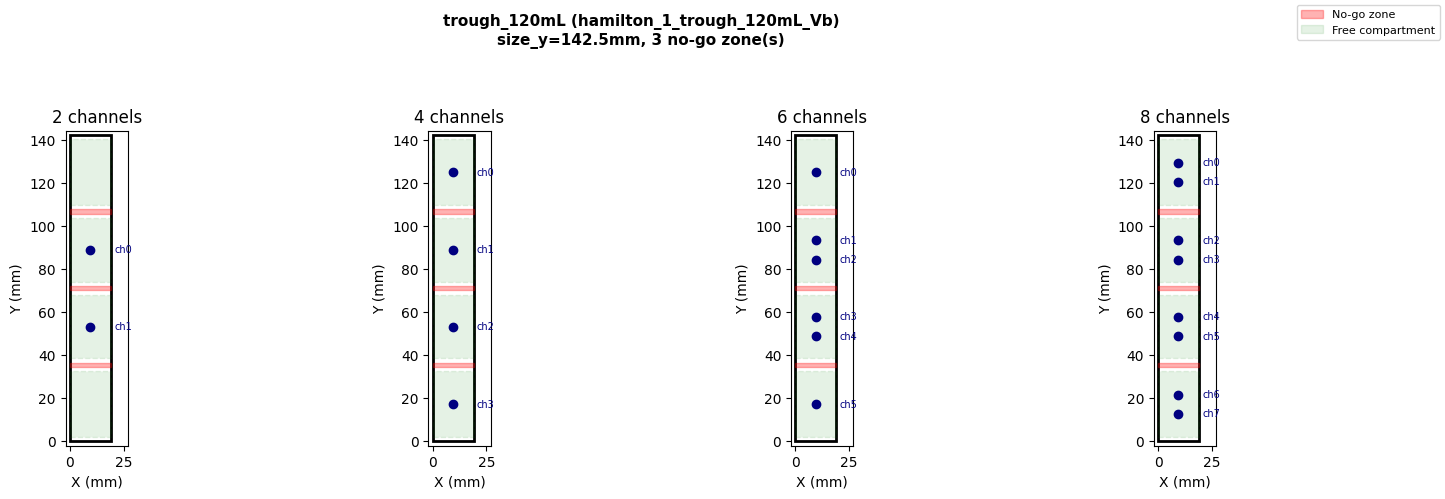

In [4]:
trough_120 = hamilton_1_trough_120mL_Vb("trough_120mL")
print(f"No-go zones: {trough_120.no_go_zones}")
print(f"Compartments: {_get_compartments(trough_120)}")
plot_container_cross_section(trough_120, [2, 4, 6, 8])

## Case 3: Container without no-go zones

A container without internal obstructions. `center_channels_in_compartments` returns `None`, and `LiquidHandler` falls through to normal spreading logic.

In [5]:
trough_200 = hamilton_1_trough_200mL_Vb("trough_200mL")
print(f"No-go zones: {trough_200.no_go_zones}")
print(f"center_channels_in_compartments returns: {center_channels_in_compartments(trough_200, 3)}")
print("-> None means: no no-go zones, use normal spreading logic")

No-go zones: []
center_channels_in_compartments returns: None
-> None means: no no-go zones, use normal spreading logic


## Case 4: Small compartments and edge clearance

`edge_clearance` (default: `MIN_SPACING_EDGE = 2mm`) controls where the **automatic channel positioning** algorithm places tip centers — it keeps them 2mm away from walls and no-go zones to avoid accidental contact during multi-channel spreading.

It does **not** prevent a pipette from physically entering a container. Whether a tip fits inside a container is determined by the tip's physical diameter vs. the container's opening — for example, a 1000 µL tip won't fit into a 1536-wellplate well. This is the **user's responsibility** to enforce when selecting tips and containers for a protocol. PyLabRobot will not block you from commanding a channel into a container that is too narrow for the attached tip.

Container size_y: 20.0mm
No-go zone: Y=8-12mm → two 8mm raw compartments
After 2mm edge clearance: compartments = [(2.0, 6.0), (14.0, 18.0)]
1 channel: [Coordinate(x=0, y=6.0, z=0)]
2 channels (1 per compartment): [Coordinate(x=0, y=6.0, z=0), Coordinate(x=0, y=-6.0, z=0)]
3 channels (needs 2 in one 4mm compartment → fails): None


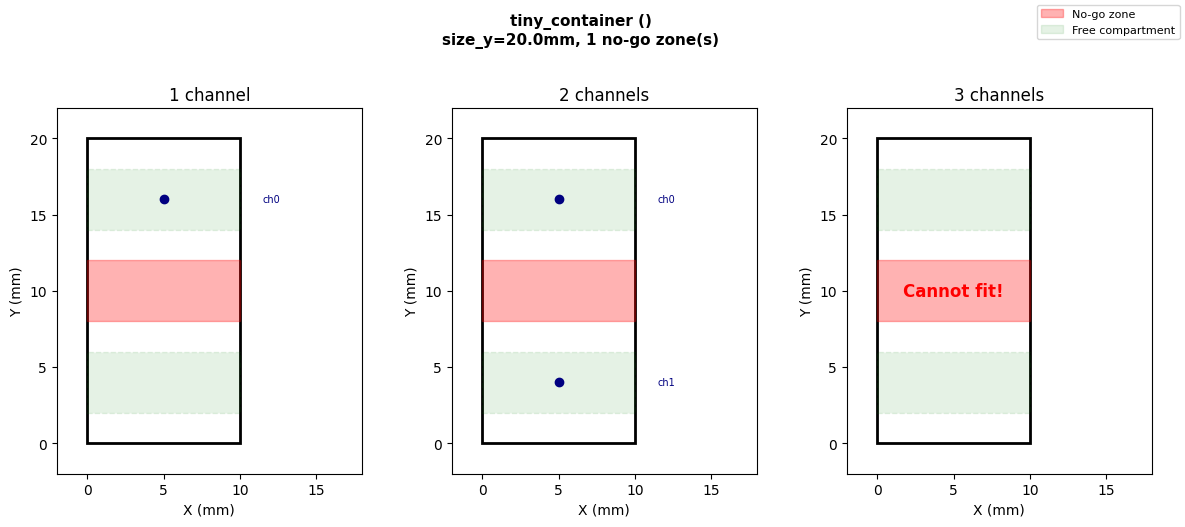

In [6]:
# A narrow container where compartments are smaller than the default 9mm channel spacing.
# 1 channel per compartment still works — the channel is simply centered.
# 2 channels in one compartment would fail (needs 9mm, only 4mm available).
tiny = Container(
    name="tiny_container", size_x=10, size_y=20, size_z=10,
    no_go_zones=[(Coordinate(0, 8, 0), Coordinate(10, 12, 10))],
)
print(f"Container size_y: {tiny.get_absolute_size_y()}mm")
print(f"No-go zone: Y={8}-{12}mm → two 8mm raw compartments")
print(f"After 2mm edge clearance: compartments = {_get_compartments(tiny)}")
print(f"1 channel: {center_channels_in_compartments(tiny, 1)}")
print(f"2 channels (1 per compartment): {center_channels_in_compartments(tiny, 2)}")
print(f"3 channels (needs 2 in one 4mm compartment → fails): {center_channels_in_compartments(tiny, 3)}")
plot_container_cross_section(tiny, [1, 2, 3])

## Case 5: Custom container

Edit the parameters below to investigate any container geometry.

Compartments: [(2.0, 28.0), (34.0, 63.0), (69.0, 98.0)]
  1 ch: ['y=-1.5']
  2 ch: ['y=+33.5', 'y=-1.5']
  3 ch: ['y=+33.5', 'y=-1.5', 'y=-35.0']
  6 ch: ['y=+38.0', 'y=+29.0', 'y=+3.0', 'y=-6.0', 'y=-30.5', 'y=-39.5']


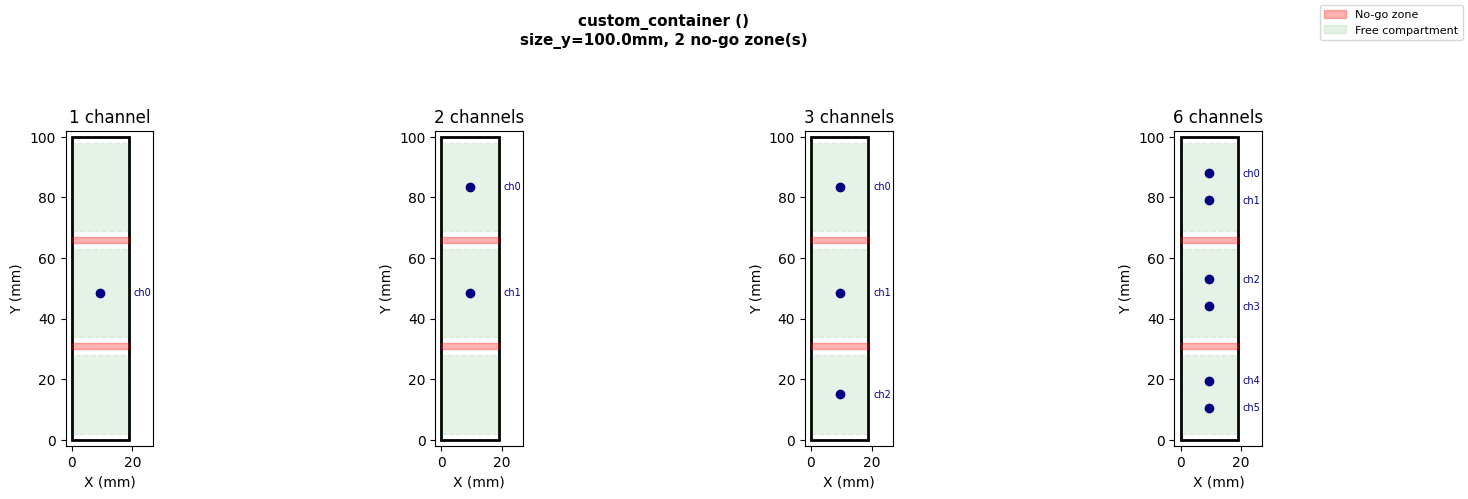

In [7]:
# --- Edit these ---
CONTAINER_SIZE_X = 19.0   # mm
CONTAINER_SIZE_Y = 100.0  # mm
CONTAINER_SIZE_Z = 50.0   # mm

# List of (y_start, y_end) pairs for no-go zones
NO_GO_Y_RANGES = [
    (30, 32),   # divider 1
    (65, 67),   # divider 2
]

NUM_CHANNELS = [1, 2, 3, 6]  # channel counts to plot
# ------------------

no_go_zones = [
    (Coordinate(0, y_lo, 0), Coordinate(CONTAINER_SIZE_X, y_hi, CONTAINER_SIZE_Z))
    for y_lo, y_hi in NO_GO_Y_RANGES
]

custom = Container(
    name="custom_container",
    size_x=CONTAINER_SIZE_X,
    size_y=CONTAINER_SIZE_Y,
    size_z=CONTAINER_SIZE_Z,
    no_go_zones=no_go_zones,
)

print(f"Compartments: {_get_compartments(custom)}")
for n in NUM_CHANNELS:
    result = center_channels_in_compartments(custom, n)
    status = [f"y={o.y:+.1f}" for o in result] if result else "Cannot fit"
    print(f"  {n} ch: {status}")

plot_container_cross_section(custom, NUM_CHANNELS)

## Case 6: End-to-end simulation

Running actual aspirate commands against the trough in simulation to verify computed offsets. This example uses a Hamilton STAR (via `STARChatterboxBackend`), but the no-go zone logic runs in `LiquidHandler` and works with any backend.

In [8]:
from pylabrobot.liquid_handling import LiquidHandler
from pylabrobot.liquid_handling.backends.hamilton.STAR_chatterbox import STARChatterboxBackend
from pylabrobot.resources.hamilton import STARLetDeck
from pylabrobot.resources.hamilton.tip_racks import hamilton_96_tiprack_1000uL_filter
from pylabrobot.resources.hamilton.trough_carriers import Trough_CAR_5R60_A00
from pylabrobot.resources import TIP_CAR_480_A00, set_tip_tracking, set_volume_tracking

set_tip_tracking(True)
set_volume_tracking(True)

backend = STARChatterboxBackend(num_channels=8)
deck = STARLetDeck()
lh = LiquidHandler(backend=backend, deck=deck)
await lh.setup()

# Set up tip carrier at rails 1
tip_car = TIP_CAR_480_A00(name="tip_carrier")
tip_car[0] = hamilton_96_tiprack_1000uL_filter(name="tips_1000")
deck.assign_child_resource(tip_car, rails=1)

# Set up trough carrier at rails 10
trough_car = Trough_CAR_5R60_A00(name="trough_carrier")
trough_car[0] = hamilton_1_trough_60mL_Vb(name="trough_60")
deck.assign_child_resource(trough_car, rails=10)

trough = deck.get_resource("trough_60")
print(f"Trough on deck: {trough.name}")
print(f"No-go zones: {trough.no_go_zones}")
print(f"Absolute location: {trough.get_absolute_location()}")

Trough on deck: trough_60
No-go zones: [(Coordinate(x=0, y=44.0, z=0), Coordinate(x=19.0, y=46.0, z=65.5))]
Absolute location: Coordinate(304.000, 070.000, 163.500)


### Pick up tips and set trough volume

In [9]:
tip_rack = deck.get_resource("tips_1000")
await lh.pick_up_tips(tip_rack["A1:D1"])  # pick up 4 tips on channels 0-3

# Fill the trough so we can aspirate
trough.tracker.set_volume(50_000)  # 50 mL
print(f"Trough volume: {trough.tracker.get_used_volume()} uL")

C0TTid0001tt01tf1tl0871tv10650tg3tu0
C0TPid0002xp01179 01179 01179 01179 00000&yp1458 1368 1278 1188 0000&tm1 1 1 1 0&tt01tp2266tz2166th2450td0
Trough volume: 50000 uL


### Aspirate with multiple channels from the trough

`LiquidHandler.aspirate` calls `center_channels_in_compartments` to distribute channels across compartments, using `backend.get_channel_spacings()` for per-channel spacing constraints. The chatterbox backend prints the raw commands so we can inspect the Y positions.

1 channels: offsets = ['+23.0']
2 channels: offsets = ['+23.0', '-23.0']
3 channels: offsets = ['+27.5', '+18.5', '-23.0']
4 channels: offsets = ['+27.5', '+18.5', '-18.5', '-27.5']


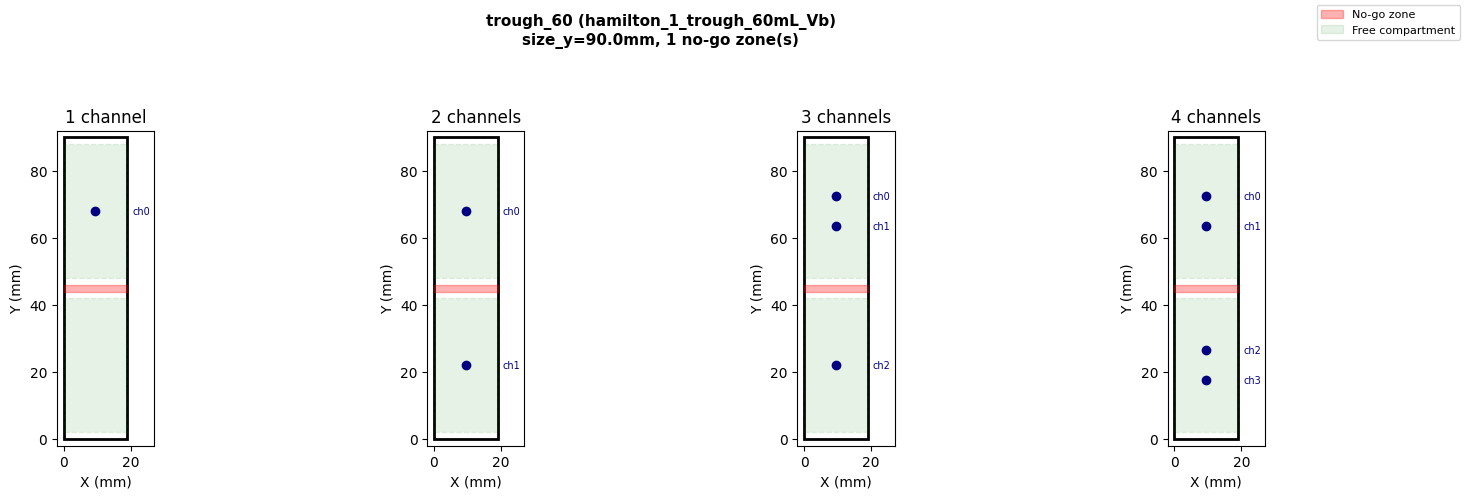

In [10]:
# First, show the expected compartment offsets for this trough
trough = deck.get_resource("trough_60")
for n in [1, 2, 3, 4]:
    offsets = center_channels_in_compartments(trough, n)
    if offsets:
        print(f"{n} channels: offsets = {[f'{o.y:+.1f}' for o in offsets]}")
    else:
        print(f"{n} channels: Cannot fit")

# Plot it
plot_container_cross_section(trough, [1, 2, 3, 4])

### Aspirate 100 uL with 2 channels (1 per compartment)

The raw command printed below contains `yp` (Y position) values — these are the absolute Y positions in 0.1mm units. Verify they land in separate compartments.

In [11]:
await lh.aspirate([trough] * 2, vols=[100, 100], use_channels=[0, 1])

C0ASid0003at0 0 0&tm1 1 0&xp03135 03135 00000&yp1380 0920 0000&th2450te2450lp2356 2356 2356&ch000 000 000&zl1651 1651 1651&po0100 0100 0100&zu0032 0032 0032&zr06180 06180 06180&zx1651 1651 1651&ip0000 0000 0000&it0 0 0&fp0000 0000 0000&av01083 01083 01083&as2500 2500 2500&ta000 000 000&ba0000 0000 0000&oa000 000 000&lm0 0 0&ll1 1 1&lv1 1 1&zo000 000 000&ld00 00 00&de0020 0020 0020&wt10 10 10&mv00000 00000 00000&mc00 00 00&mp000 000 000&ms1000 1000 1000&mh0000 0000 0000&gi000 000 000&gj0gk0lk0 0 0&ik0000 0000 0000&sd0500 0500 0500&se0500 0500 0500&sz0300 0300 0300&io0000 0000 0000&


### Aspirate 100 uL with 4 channels (2 per compartment)

In [12]:
await lh.aspirate([trough] * 4, vols=[100] * 4, use_channels=[0, 1, 2, 3])

C0ASid0004at0 0 0 0 0&tm1 1 1 1 0&xp03135 03135 03135 03135 00000&yp1425 1335 0965 0875 0000&th2450te2450lp2356 2356 2356 2356 2356&ch000 000 000 000 000&zl1651 1651 1651 1651 1651&po0100 0100 0100 0100 0100&zu0032 0032 0032 0032 0032&zr06180 06180 06180 06180 06180&zx1651 1651 1651 1651 1651&ip0000 0000 0000 0000 0000&it0 0 0 0 0&fp0000 0000 0000 0000 0000&av01083 01083 01083 01083 01083&as2500 2500 2500 2500 2500&ta000 000 000 000 000&ba0000 0000 0000 0000 0000&oa000 000 000 000 000&lm0 0 0 0 0&ll1 1 1 1 1&lv1 1 1 1 1&zo000 000 000 000 000&ld00 00 00 00 00&de0020 0020 0020 0020 0020&wt10 10 10 10 10&mv00000 00000 00000 00000 00000&mc00 00 00 00 00&mp000 000 000 000 000&ms1000 1000 1000 1000 1000&mh0000 0000 0000 0000 0000&gi000 000 000 000 000&gj0gk0lk0 0 0 0 0&ik0000 0000 0000 0000 0000&sd0500 0500 0500 0500 0500&se0500 0500 0500 0500 0500&sz0300 0300 0300 0300 0300&io0000 0000 0000 0000 0000&


### Cleanup

In [13]:
await lh.stop()